In [2]:
!pip install openpyxl
!pip install matplotlib
!pip install seaborn
!pip install scipy
!pip install scikit-learn

In [3]:
import pandas as pd
import numpy as np

# four experimental groups
'''
s1: B27	    Ctrl
s2: B27 	MitoMutant
s3: OxlQ	MitoMutant
s4: OxlQ	Ctrl
'''

metadata = pd.DataFrame({
    "sample": ["s1", "s2", "s3", "s4"],
    "medium": ["B27", "B27", "OxIQ", "OxIQ"],
    "mitochondrial_status": [
        "control",
        "mutant",
        "mutant",
        "control"
    ]
})

print("metadata:\n", metadata)


metadata:
   sample medium mitochondrial_status
0     s1    B27              control
1     s2    B27               mutant
2     s3   OxIQ               mutant
3     s4   OxIQ              control


In [26]:
met_file = "data/SUB16387_metabolomicsData.xlsx"
xls_met = pd.ExcelFile(met_file)

df = pd.read_excel(met_file, sheet_name=xls_met.sheet_names[1], skiprows=7)  # skip the first seven rows, eighth row is the header row
# print(xls_met.sheet_names[1])
print(df.head(3))
feature_info = df[["Name", "Formula", "RT [min]"]]



                Ref              Name Tags        Formula  \
0  183.06597@15.268    Phosphocholine   L1  C5 H14 N O4 P   
1   266.15404@1.847   Dodecyl sulfate   L2   C12 H26 O4 S   
2    184.14618@3.98  Undecylenic acid   L2     C11 H20 O2   

   Annot. DeltaMass [Da]  Annot. DeltaMass [ppm]   Calc. MW        m/z  \
0               -0.00007                   -0.40  183.06597  184.07325   
1               -0.00114                   -4.30  266.15404  265.14676   
2               -0.00015                   -0.84  184.14618  202.18000   

  Reference Ion  RT [min]  ... Norm. Area: SUB16387_W2_SPL02.raw (F2)  \
0       [M+H]+1    15.268  ...                           1.834779e+10   
1       [M-H]-1     1.847  ...                           6.814549e+09   
2     [M+NH4]+1     3.980  ...                           4.193670e+09   

   Norm. Area: SUB16387_W2_SPL03.raw (F3)  \
0                            2.391372e+10   
1                            8.336201e+09   
2                            3

/Users/safazaidmalik/Documents/MMHP/metabolomics_vis/.venv/lib/python3.13/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Conditional Formatting extension is not supported and will be removed
  warn(msg)


In [27]:
df.rename(columns={'Area: SUB16387_W2_SPL01.raw (F1)': 'F1, B27, Ctrl',
                'Area: SUB16387_W2_SPL02.raw (F2)':'F2, B27, Ctrl',
                'Area: SUB16387_W2_SPL03.raw (F3)':'F3, B27, Ctrl',
                'Area: SUB16387_W2_SPL04.raw (F4)':'F4, B27, MitoMutant',
                'Area: SUB16387_W2_SPL05.raw (F5)':'F5, OxIQ, MitoMutant',
                'Area: SUB16387_W2_SPL06.raw (F6)':'F6, OxIQ, Ctrl',
                'Area: SUB16387_W2_SPL07.raw (F7)':'F7, OxIQ, Ctrl',
                'Area: SUB16387_W2_SPL08.raw (F8)':'F8, OxIQ, Ctrl'},
           inplace=True)
print("Renamed columns:\n", df.columns)
df[['F1, B27, Ctrl']].head(3)
# df.head(3)


Renamed columns:
 Index(['Ref', 'Name', 'Tags', 'Formula', 'Annot. DeltaMass [Da]',
       'Annot. DeltaMass [ppm]', 'Calc. MW', 'm/z', 'Reference Ion',
       'RT [min]', 'Polarity', 'Area (Max.)', 'mzCloud Best Match',
       'mzCloud Best Match Confidence', 'mzVault Best Match', 'Grade',
       'Class Name', 'MS2', 'MS Depth', 'MS2 Purity [%]',
       'Group Area: B27, Ctrl', 'Group CV [%]: B27, Ctrl',
       'Group Area: B27, MitoMutant', 'Group CV [%]: B27, MitoMutant',
       'Group Area: OxlQ, Ctrl', 'Group CV [%]: OxlQ, Ctrl',
       'Group Area: OxlQ, MitoMutant', 'Group CV [%]: OxlQ, MitoMutant',
       'Ratio: (B27, Ctrl) / (OxlQ, Ctrl)',
       'Log2 Fold Change: (B27, Ctrl) / (OxlQ, Ctrl)',
       'P-value: (B27, Ctrl) / (OxlQ, Ctrl)',
       'Ratio: (B27, MitoMutant) / (B27, Ctrl)',
       'Log2 Fold Change: (B27, MitoMutant) / (B27, Ctrl)',
       'P-value: (B27, MitoMutant) / (B27, Ctrl)',
       'Ratio: (B27, MitoMutant) / (OxlQ, MitoMutant)',
       'Log2 Fold Change:

,"F1, B27, Ctrl"
0,2.328961e+10
1,1.107125e+10
2,8.034593e+09


In [28]:
# Abundance matrix for each sample group
abundance = df[["Group Area: B27, Ctrl",
                "Group Area: B27, MitoMutant",
                "Group Area: OxlQ, Ctrl",
                "Group Area: OxlQ, MitoMutant"
            ]]

print(abundance.head(3))

   Group Area: B27, Ctrl  Group Area: B27, MitoMutant  Group Area: OxlQ, Ctrl  \
0           2.328961e+10                 4.720084e+09            1.314689e+10   
1           8.336201e+09                 4.169415e+09            1.923150e+08   
2           4.193670e+09                 1.792087e+09            5.079485e+09   

   Group Area: OxlQ, MitoMutant  
0                  7.216744e+08  
1                  4.829124e+09  
2                  1.844395e+09  


In [29]:
# Check for missing values
missing = abundance.isna().sum()
print("Missing values in abundance data:\n", missing)

# Check for the proportion of missing (NaN) values in each row of df
missing_fraction = abundance.isna().mean(axis=1)
# missing_fraction.describe()

Missing values in abundance data:
 Group Area: B27, Ctrl           1
Group Area: B27, MitoMutant     1
Group Area: OxlQ, Ctrl          1
Group Area: OxlQ, MitoMutant    1
dtype: int64


In [30]:
import matplotlib.pyplot as plt
# Examine raw sample intensity
print("abundance statistics:\n", abundance.describe())
print("abundance shape:\n", abundance.shape)

# median signal is already provided in the source data in these columns
sample_medians = abundance.sum(axis=0)
print("Sample medians:\n", sample_medians)
# sample_medians.plot(
#     kind='bar',
#     title='Median Metabolite Signal per Group',
#     ylabel='Total Signal',
#     xlabel='Group',
#     figsize=(8,5)
# )
# plt.show()

sample_median_log10 = np.log10(abundance)
print("Sample medians (log10):\n", sample_median_log10)
# sample_median_log10.plot(
#     kind='bar',
#     title='Log10 Median Metabolite Signal per Group',
#     ylabel='Log10 (Signal)',
#     xlabel='Group',
#     figsize=(8,5)
# )
# plt.show()


abundance statistics:
        Group Area: B27, Ctrl  Group Area: B27, MitoMutant  \
count           1.223000e+03                 1.223000e+03   
mean            1.618686e+08                 1.883556e+08   
std             8.715698e+08                 9.930016e+08   
min             1.955417e+04                 4.257171e+04   
25%             4.949736e+06                 3.660458e+06   
50%             1.639474e+07                 1.568341e+07   
75%             6.622501e+07                 5.955571e+07   
max             2.328961e+10                 2.133818e+10   

       Group Area: OxlQ, Ctrl  Group Area: OxlQ, MitoMutant  
count            1.223000e+03                  1.223000e+03  
mean             2.580791e+08                  1.968067e+08  
std              1.309507e+09                  1.052204e+09  
min              3.603527e+04                  2.652163e+04  
25%              1.792753e+06                  3.984209e+06  
50%              1.118878e+07                  1.517854

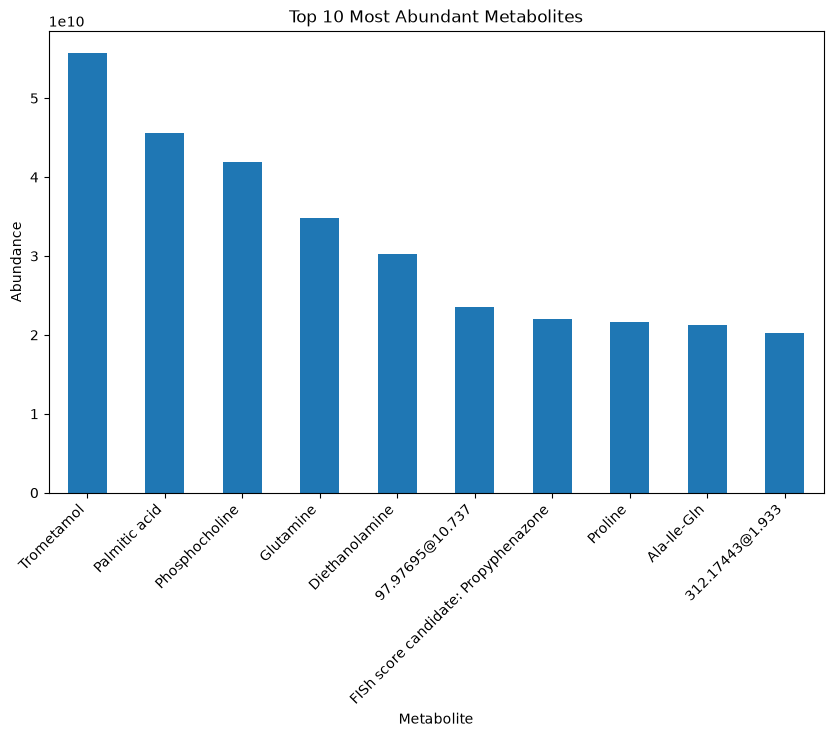

In [31]:
# The 10 overall most abundant metabolites and their respective abundance distributions
top10_metabolites = abundance.sum(axis=1).nlargest(10)
feature_info = df[["Ref", "Name", "Formula", "RT [min]"]]
xticks = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
xvalues = (
    feature_info.loc[top10_metabolites.index, "Name"]
    .fillna(feature_info.loc[top10_metabolites.index, "Ref"])
    .tolist()
)

top10_metabolites.plot(kind='bar', title='Top 10 Most Abundant Metabolites', ylabel='Abundance', xlabel='Metabolite', figsize=(10,6))
plt.xticks([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], labels=xvalues, rotation=45, ha='right')
plt.show()

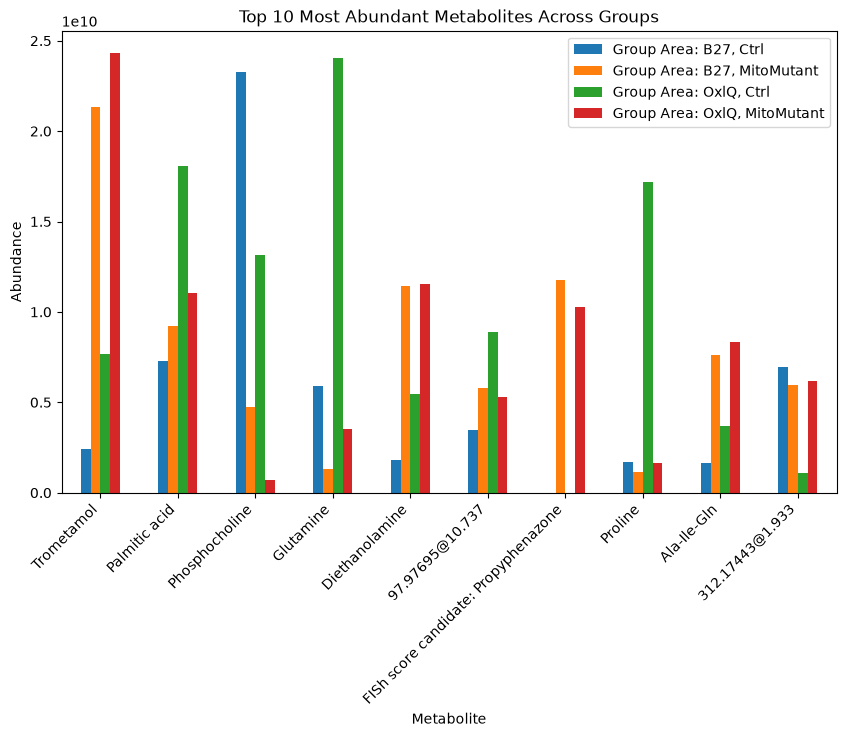

In [32]:
# The 10 abundance of the top 10 metabolites across the four experimental groups
top10_abundance = abundance.loc[top10_metabolites.index]
top10_abundance.plot(kind='bar', title='Top 10 Most Abundant Metabolites Across Groups', ylabel='Abundance', xlabel='Metabolite', figsize=(10,6))
plt.xticks([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], labels=xvalues, rotation=45, ha='right')
plt.show()

Some metabolites are labeled by their respective reference IDs due to low certainty about their identity after MS detection.

raw abundance statistics:
        F1, B27, Ctrl  F2, B27, Ctrl  F3, B27, Ctrl  F4, B27, MitoMutant  \
count   1.224000e+03   1.224000e+03   1.224000e+03         1.224000e+03   
mean    1.878427e+08   6.055175e+07   9.594931e+07         2.903980e+07   
std     1.122019e+09   3.333102e+08   5.800554e+08         1.513562e+08   
min     1.822861e+04   5.977955e+03   8.832639e+03         6.436973e+03   
25%     3.181485e+06   1.468934e+06   2.576601e+06         5.535792e+05   
50%     1.720163e+07   5.308213e+06   8.618649e+06         2.379625e+06   
75%     7.002919e+07   2.119091e+07   3.562627e+07         9.057989e+06   
max     2.328975e+10   6.464647e+09   1.237767e+10         3.226398e+09   

       F5, OxIQ, MitoMutant  F6, OxIQ, Ctrl  F7, OxIQ, Ctrl  F8, OxIQ, Ctrl  
count          1.224000e+03    1.224000e+03    1.224000e+03    1.224000e+03  
mean           2.878018e+07    8.929954e+07    6.071392e+07    5.724244e+07  
std            1.534882e+08    4.106951e+08    3.255875e+08    

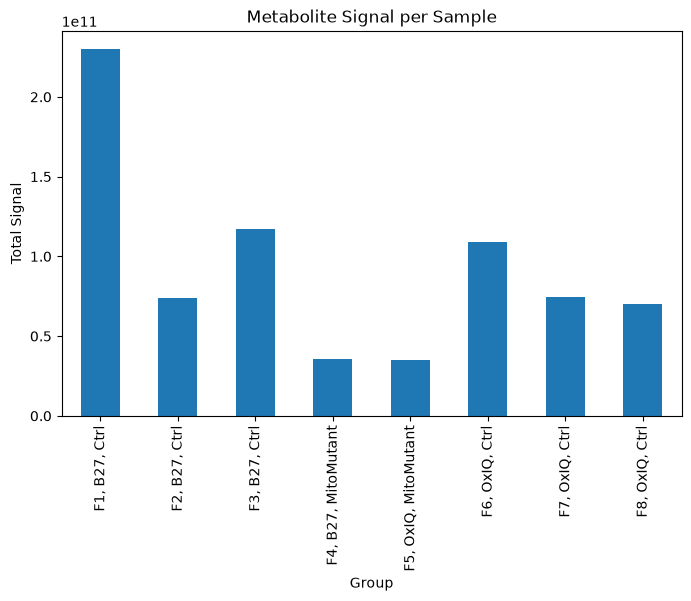

In [33]:
# Abundance matrix for each sample group

'''
df.rename(columns={'Area: SUB16387_W2_SPL01.raw (F1)': 'F1, B27, Ctrl',
                'Area: SUB16387_W2_SPL02.raw (F2)':'F2, B27, Ctrl',
                'Area: SUB16387_W2_SPL03.raw (F3)':'F3, B27, Ctrl',
                'Area: SUB16387_W2_SPL04.raw (F4)':'F4, B27, MitoMutant',
                'Area: SUB16387_W2_SPL05.raw (F5)':'F5, OxIQ, MitoMutant',
                'Area: SUB16387_W2_SPL06.raw (F6)':'F6, OxIQ, Ctrl',
                'Area: SUB16387_W2_SPL07.raw (F7)':'F7, OxIQ, Ctrl',
                'Area: SUB16387_W2_SPL08.raw (F8)':'F8, OxIQ, Ctrl'},
           inplace=True)
'''

raw_abundance = df[["F1, B27, Ctrl",
                "F2, B27, Ctrl",
                "F3, B27, Ctrl",
                "F4, B27, MitoMutant",
                "F5, OxIQ, MitoMutant",
                "F6, OxIQ, Ctrl",
                "F7, OxIQ, Ctrl",
                "F8, OxIQ, Ctrl"
            ]]


# print(raw_abundance.head(3))

# Examine raw sample intensity
print("raw abundance statistics:\n", raw_abundance.describe())
# print("raw abundance shape:\n", raw_abundance.shape)

# median signal is already provided in the source data in these columns
sample = raw_abundance.sum(axis=0)
# print("Sample totals:\n", sample)
sample.plot(
    kind='bar',
    title='Metabolite Signal per Sample',
    ylabel='Total Signal',
    xlabel='Group',
    figsize=(8,5)
)
plt.show()

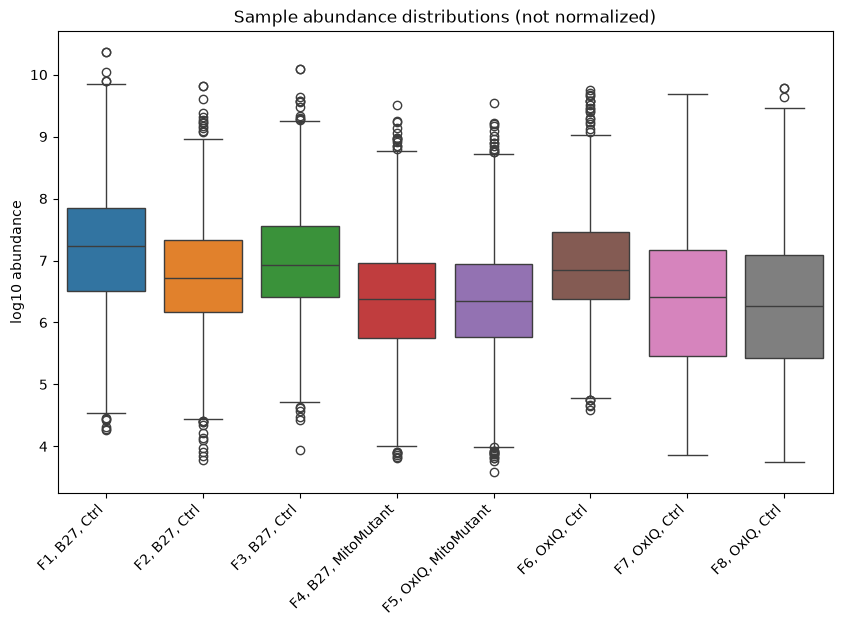

In [34]:
import seaborn as sns
import matplotlib.pyplot as plt

# Log transform raw abundance data
log_abundance = np.log10(raw_abundance + 1) # Adding 1 to avoid log(0)

plt.figure(figsize=(10,6))
# for sample in log_abundance.columns:
#     sns.kdeplot(log_abundance[sample], label=sample)
# plt.title('Density Plot of Log2 Transformed Abundance Data')
# plt.xlabel('Log2 Abundance')
# plt.ylabel('Density')
# plt.legend()
# plt.show()

sns.boxplot(data=log_abundance)

plt.ylabel("log10 abundance")
plt.title("Sample abundance distributions (not normalized)")
plt.xticks([0,1,2,3,4,5,6,7], labels=log_abundance.columns, rotation=45, ha='right')
plt.show()

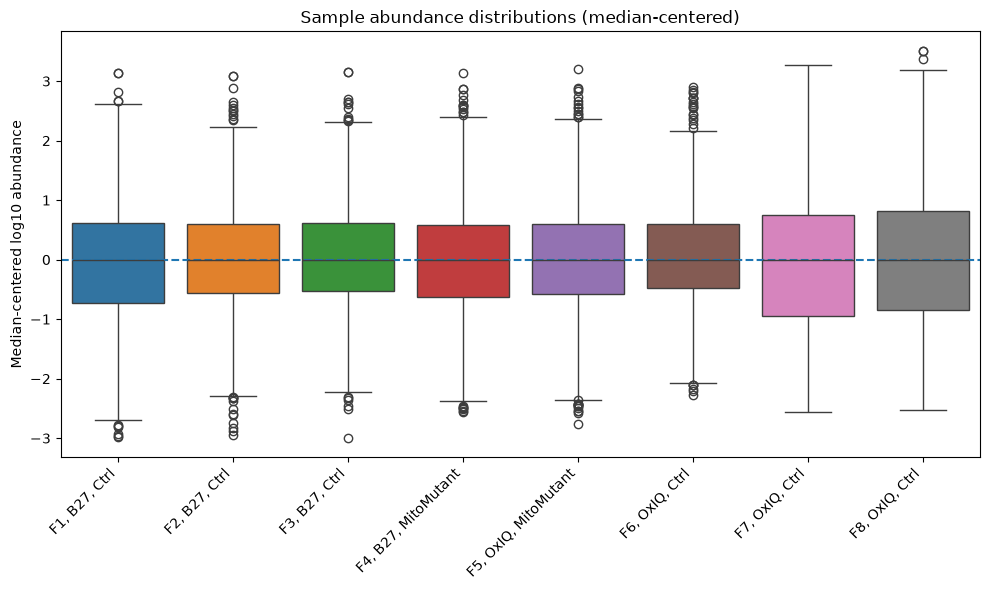

In [35]:
# Median centerd boxplots
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Log transform
log_abundance = np.log10(raw_abundance + 1)

# For each sample column, calculate the median across all metabolites:
sample_medians = log_abundance.median(axis=0)
# Then median-center each sample
median_centered = log_abundance.subtract(sample_medians, axis=1)

median_centered.median(axis=0)

# Median-center each sample
# median_centered = log_abundance.subtract(
#     log_abundance.median(axis=0),
#     axis=1
# )

# Plot
plt.figure(figsize=(10, 6))

sns.boxplot(data=median_centered)

plt.ylabel("Median-centered log10 abundance")
plt.title("Sample abundance distributions (median-centered)")
plt.xticks(
    range(len(median_centered.columns)),
    median_centered.columns,
    rotation=45,
    ha='right'
)
plt.axhline(0, linestyle='--')
plt.tight_layout()
plt.show()

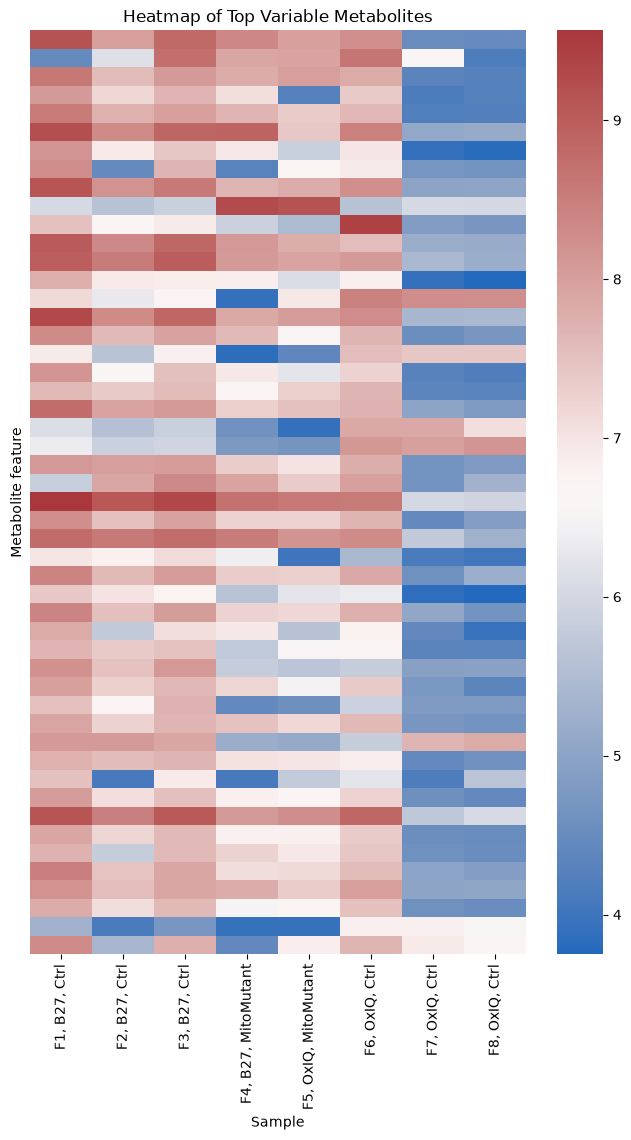

In [36]:
# Heatmap to show the most variable metabolites across the four groups
feature_variance = log_abundance.var(axis=1)
top_features = feature_variance.nlargest(50).index
heatmap_data = log_abundance.loc[top_features]

plt.figure(figsize=(8, 12))
sns.heatmap(heatmap_data, cmap='vlag', xticklabels=True, yticklabels=False)
plt.title("Heatmap of Top Variable Metabolites")
plt.xlabel("Sample")
plt.ylabel("Metabolite feature")
plt.show()

In [37]:
groups = {
    "F1": "B27 Ctrl",
    "F2": "B27 Ctrl",
    "F3": "B27 Ctrl",
    "F4": "B27 MitoMutant",
    "F5": "OxIQ MitoMutant",
    "F6": "OxIQ Ctrl",
    "F7": "OxIQ Ctrl",
    "F8": "OxIQ Ctrl"
}

# Extract F1, F2, etc. from the column names
sample_ids = heatmap_data.columns.str.extract(r"\((F\d+)\)$", expand=False)

# Assign each sample to its group, preserving the original column order
group_labels = pd.Series(sample_ids.to_numpy(), index=heatmap_data.columns).map(groups)

# Map groups to colors
color_map = {
    "B27 Ctrl": "blue",
    "B27 MitoMutant": "orange",
    "OxIQ Ctrl": "green",
    "OxIQ MitoMutant": "red"
}

col_colors = group_labels.map(color_map)

# Check that every sample has a group and color
print(group_labels)
print(col_colors)

F1, B27, Ctrl           NaN
F2, B27, Ctrl           NaN
F3, B27, Ctrl           NaN
F4, B27, MitoMutant     NaN
F5, OxIQ, MitoMutant    NaN
F6, OxIQ, Ctrl          NaN
F7, OxIQ, Ctrl          NaN
F8, OxIQ, Ctrl          NaN
dtype: str
F1, B27, Ctrl           NaN
F2, B27, Ctrl           NaN
F3, B27, Ctrl           NaN
F4, B27, MitoMutant     NaN
F5, OxIQ, MitoMutant    NaN
F6, OxIQ, Ctrl          NaN
F7, OxIQ, Ctrl          NaN
F8, OxIQ, Ctrl          NaN
dtype: str


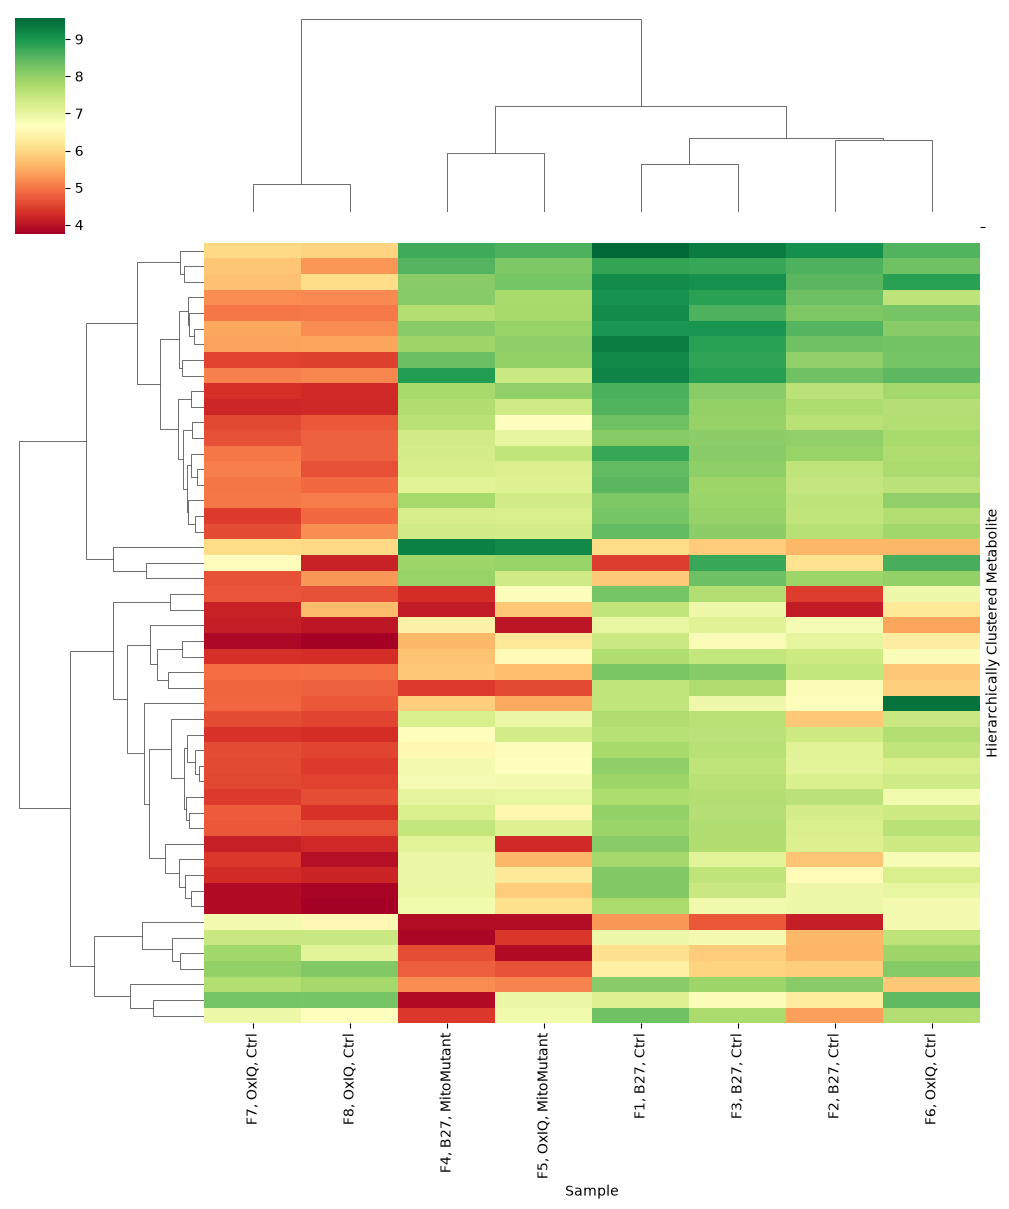

In [38]:
import scipy

# groups = {
#     "F1": "B27 Ctrl",
#     "F2": "B27 Ctrl",
#     "F3": "B27 Ctrl",
#     "F4": "B27 MitoMutant",
#     "F5": "OxIQ MitoMutant",
#     "F6": "OxIQ Ctrl",
#     "F7": "OxIQ Ctrl",
#     "F8": "OxIQ Ctrl"
# }

# group_labels = heatmap_data.columns.map(groups)

# if group_labels.isna().any():
#     print("Missing group assignments for:")
#     print(heatmap_data.columns[group_labels.isna()].tolist())


g = sns.clustermap(
    heatmap_data,
    method="complete",
    metric="Euclidean",
    row_cluster=True,
    col_cluster=True,
    cmap='RdYlGn',
    col_colors=col_colors,
    xticklabels=True,
    yticklabels=False,
    figsize=(10, 12)
)
# g.ax_heatmap.set_title("Hierarchical Clustering of Top Variable Metabolites")
g.ax_heatmap.set_xlabel("Sample")
g.ax_heatmap.set_ylabel("Hierarchically Clustered Metabolite")
plt.show()

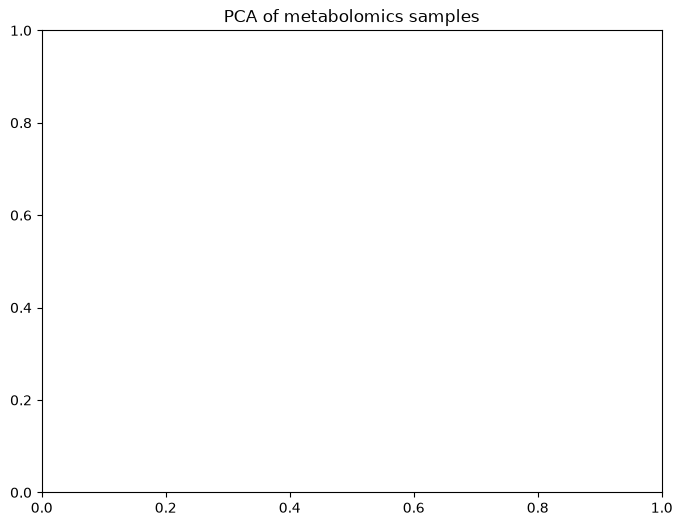

In [39]:
# PCA plot 
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

X = log_abundance.T

X_scaled = StandardScaler().fit_transform(X)

pca = PCA(n_components=2)

principal_components = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(
    principal_components,
    columns=["PC1", "PC2"],
    index=X.index
)

# pca_df
sample_groups = {
    "s1": "B27 control",
    "s2": "B27 mito mutant",
    "s3": "OxIQ mito mutant",
    "s4": "OxIQ control"
}
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue=pca_df.index.map(sample_groups),
    s=150
)

plt.title("PCA of metabolomics samples")
plt.show()